### Feature Selection

#### Nama : Alexander Ricky
#### NIM 255314035

In [5]:
# ============================================
# TAHAP 0
# Membaca data
# ============================================
import pandas as pd
import numpy as np
## Baca data file nba terlampir simpan dengan nama df
nba_df= pd.read_csv("all_seasons.csv")
## Tampilkan isi df
nba_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12844 entries, 0 to 12843
Data columns (total 22 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         12844 non-null  int64  
 1   player_name        12844 non-null  object 
 2   team_abbreviation  12844 non-null  object 
 3   age                12844 non-null  float64
 4   player_height      12844 non-null  float64
 5   player_weight      12844 non-null  float64
 6   college            10990 non-null  object 
 7   country            12844 non-null  object 
 8   draft_year         12844 non-null  object 
 9   draft_round        12844 non-null  object 
 10  draft_number       12844 non-null  object 
 11  gp                 12844 non-null  int64  
 12  pts                12844 non-null  float64
 13  reb                12844 non-null  float64
 14  ast                12844 non-null  float64
 15  net_rating         12844 non-null  float64
 16  oreb_pct           128

In [6]:
nba_df.isnull().sum()

Unnamed: 0              0
player_name             0
team_abbreviation       0
age                     0
player_height           0
player_weight           0
college              1854
country                 0
draft_year              0
draft_round             0
draft_number            0
gp                      0
pts                     0
reb                     0
ast                     0
net_rating              0
oreb_pct                0
dreb_pct                0
usg_pct                 0
ts_pct                  0
ast_pct                 0
season                  0
dtype: int64

In [7]:
nba_df["college"] = nba_df["college"].fillna("Unknown")
nba_df.isnull().sum()

Unnamed: 0           0
player_name          0
team_abbreviation    0
age                  0
player_height        0
player_weight        0
college              0
country              0
draft_year           0
draft_round          0
draft_number         0
gp                   0
pts                  0
reb                  0
ast                  0
net_rating           0
oreb_pct             0
dreb_pct             0
usg_pct              0
ts_pct               0
ast_pct              0
season               0
dtype: int64

In [8]:
nba_df = nba_df.drop(columns=['Unnamed: 0'])

In [9]:
target_col = "pts"

# Fitur = semua kolom numerik selain pts
feature_cols = nba_df.select_dtypes(include='number').columns
feature_cols = feature_cols[feature_cols != target_col]

In [10]:
# ============================================
# TAHAP 1
# VARIANCE THRESHOLD
# ============================================
x_features = nba_df[feature_cols]
y_target = nba_df[target_col]

var_scores = x_features.var()

print("\n--- TAHAP 1: VARIANCE ---")
print(var_scores.sort_values(ascending=False))


--- TAHAP 1: VARIANCE ---
gp               629.252415
net_rating       160.405369
player_weight    154.421085
player_height     83.011965
age               18.828749
reb                6.139912
ast                3.243024
ts_pct             0.010348
ast_pct            0.008868
dreb_pct           0.003908
usg_pct            0.002867
oreb_pct           0.001878
dtype: float64


In [11]:
print("\n--- TAHAP 1: MEAN ---")
mean_scores = x_features.mean()
print(mean_scores.sort_values(ascending=False))


--- TAHAP 1: MEAN ---
player_height    200.555097
player_weight    100.263279
gp                51.154158
age               27.045313
reb                3.558486
ast                1.824681
ts_pct             0.513138
usg_pct            0.184641
dreb_pct           0.140646
ast_pct            0.131595
oreb_pct           0.054073
net_rating        -2.226339
dtype: float64


In [12]:
from sklearn.feature_selection import VarianceThreshold

var_selector = VarianceThreshold(15)
var_selector.fit_transform(x_features)

array([[ 2.20000000e+01,  1.93040000e+02,  9.48007280e+01,
         6.40000000e+01,  3.00000000e-01],
       [ 2.80000000e+01,  1.90500000e+02,  8.61824800e+01,
         4.00000000e+00,  8.90000000e+00],
       [ 2.60000000e+01,  2.03200000e+02,  1.03418976e+02,
         4.10000000e+01, -8.20000000e+00],
       ...,
       [ 2.50000000e+01,  2.05740000e+02,  1.02511792e+02,
         7.10000000e+01, -2.00000000e-01],
       [ 2.40000000e+01,  2.08280000e+02,  1.13398000e+02,
         5.20000000e+01, -6.70000000e+00],
       [ 3.30000000e+01,  2.05740000e+02,  1.02965384e+02,
         5.70000000e+01, -8.20000000e+00]], shape=(12844, 5))

                    age  player_height  player_weight        gp       reb  \
age            1.000000      -0.007904       0.063561  0.057442  0.037386   
player_height -0.007904       1.000000       0.822141  0.004963  0.424220   
player_weight  0.063561       0.822141       1.000000  0.022828  0.438112   
gp             0.057442       0.004963       0.022828  1.000000  0.471405   
reb            0.037386       0.424220       0.438112  0.471405  1.000000   
ast            0.092359      -0.442781      -0.371675  0.382726  0.247841   
net_rating     0.092896      -0.003074       0.003547  0.248412  0.187820   
oreb_pct      -0.055228       0.589538       0.599511 -0.014763  0.407960   
dreb_pct       0.018774       0.614273       0.605639  0.067911  0.611899   
usg_pct       -0.113882      -0.104011      -0.065811  0.147248  0.232968   
ts_pct         0.025245       0.076797       0.070992  0.367876  0.313451   
ast_pct        0.069029      -0.608696      -0.521939  0.131720 -0.062654   

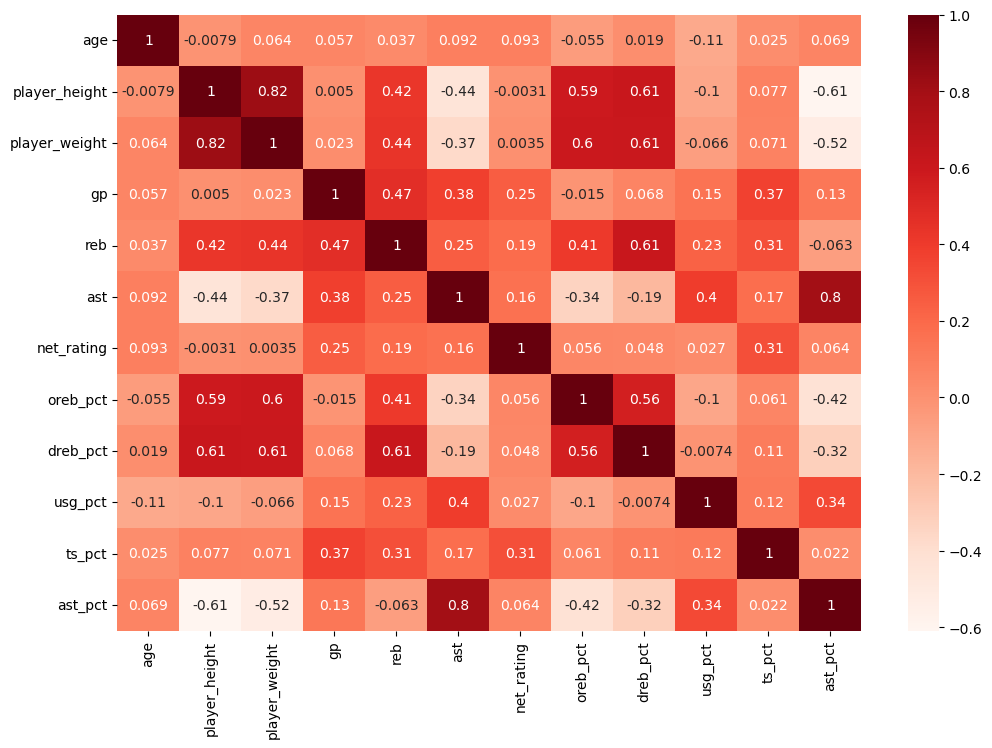

In [13]:
# ============================================
# TAHAP 2
# CORRELATION ANALYSIS
# ============================================
## Pearson correlation
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

plt.figure(figsize=(12,8))
corr_matrix = x_features.corr()
print(corr_matrix)

sns.heatmap(corr_matrix, annot=True, cmap=plt.cm.Reds)
plt.show()

In [14]:
# ============================================
# TAHAP 2B
# CORRELATION ANALYSIS
# ============================================
target_corr = x_features.corrwith(y_target)
df_corr_result = pd.DataFrame({
    "Nama_Fitur": feature_cols,
    "Pearson_r": target_corr.values,
    "Abs_r": target_corr.abs().values
})

df_corr_result = df_corr_result.sort_values(
    "Abs_r",
    ascending=False
)

print("\n--- TAHAP 2: CORRELATION ---")
print(df_corr_result)


--- TAHAP 2: CORRELATION ---
       Nama_Fitur  Pearson_r     Abs_r
5             ast   0.664320  0.664320
9         usg_pct   0.641469  0.641469
4             reb   0.624509  0.624509
3              gp   0.536003  0.536003
10         ts_pct   0.373439  0.373439
11        ast_pct   0.337339  0.337339
6      net_rating   0.215199  0.215199
7        oreb_pct  -0.125164  0.125164
8        dreb_pct   0.055669  0.055669
1   player_height  -0.055284  0.055284
2   player_weight  -0.025023  0.025023
0             age   0.011353  0.011353


In [15]:
# ============================================
# TAHAP 3
# UNIVARIATE F-TEST
# ============================================
from sklearn.feature_selection import f_regression

f_stats, p_values = f_regression(x_features, y_target)

df_univariate = pd.DataFrame({
    "Nama_Fitur": feature_cols,
    "F_statistic": f_stats,
    "p_value": p_values
})

df_univariate = df_univariate.sort_values(
    "F_statistic",
    ascending=False
)

df_univariate["Signifikan"] = (
    df_univariate["p_value"] < 0.05
)

print("\n--- TAHAP 3: UNIVARIATE ---")
print(df_univariate)


--- TAHAP 3: UNIVARIATE ---
       Nama_Fitur   F_statistic        p_value  Signifikan
5             ast  10144.361397   0.000000e+00        True
9         usg_pct   8978.923800   0.000000e+00        True
4             reb   8210.858587   0.000000e+00        True
3              gp   5176.791009   0.000000e+00        True
10         ts_pct   2081.123978   0.000000e+00        True
11        ast_pct   1649.046644   0.000000e+00        True
6      net_rating    623.602152  1.930636e-134        True
7        oreb_pct    204.385589   5.196883e-46        True
8        dreb_pct     39.921197   2.731520e-10        True
1   player_height     39.369943   3.619205e-10        True
2   player_weight      8.046000   4.567560e-03        True
0             age      1.655495   1.982359e-01       False


In [16]:
# ============================================
# TAHAP 4
# FINAL RANKING
# ============================================
df_final_rank = df_corr_result.merge(
    df_univariate,
    on="Nama_Fitur"
)

df_final_rank = df_final_rank.sort_values(
    "Abs_r",
    ascending=False
)

df_final_rank["Peringkat_Akhir"] = range(
    1,
    len(df_final_rank) + 1
)

print("\n--- TAHAP 4: FINAL RANKING ---")
print(df_final_rank)


--- TAHAP 4: FINAL RANKING ---
       Nama_Fitur  Pearson_r     Abs_r   F_statistic        p_value  \
0             ast   0.664320  0.664320  10144.361397   0.000000e+00   
1         usg_pct   0.641469  0.641469   8978.923800   0.000000e+00   
2             reb   0.624509  0.624509   8210.858587   0.000000e+00   
3              gp   0.536003  0.536003   5176.791009   0.000000e+00   
4          ts_pct   0.373439  0.373439   2081.123978   0.000000e+00   
5         ast_pct   0.337339  0.337339   1649.046644   0.000000e+00   
6      net_rating   0.215199  0.215199    623.602152  1.930636e-134   
7        oreb_pct  -0.125164  0.125164    204.385589   5.196883e-46   
8        dreb_pct   0.055669  0.055669     39.921197   2.731520e-10   
9   player_height  -0.055284  0.055284     39.369943   3.619205e-10   
10  player_weight  -0.025023  0.025023      8.046000   4.567560e-03   
11            age   0.011353  0.011353      1.655495   1.982359e-01   

    Signifikan  Peringkat_Akhir  
0         

In [17]:
# ============================================
# FINAL FEATURE SELECTION
# ============================================
chosen_features = df_final_rank.loc[
    df_final_rank["Signifikan"],
    "Nama_Fitur"
].tolist()

print("\n--- FITUR TERPILIH ---")
print(chosen_features)


--- FITUR TERPILIH ---
['ast', 'usg_pct', 'reb', 'gp', 'ts_pct', 'ast_pct', 'net_rating', 'oreb_pct', 'dreb_pct', 'player_height', 'player_weight']


In [20]:
nba_df.to_excel("dataexcel.xlsx", sheet_name="nba_allseason", index=False)
print("Berhasil disimpan!")

Berhasil disimpan!
